In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:

from pandas import read_csv
df=read_csv("/content/plate_dataset_updated.csv")

In [ ]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Reg_Month', 'Reg_Year', 'Desc_Length', 'Screw_Count', 'Width_px', 'Height_px']
Categorical Features: ['Image File', 'State', 'Plate Number', 'Reg_Month_Status', 'Reg_Year_Status', 'Top Banner/Slogan Text', 'Commemorative Text', 'Left/Corner Emblem Text', 'Plate Background Description', 'Plate Style', 'Image Orientation']


In [ ]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [ ]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
             Reg_Month  Reg_Year  Desc_Length  Screw_Count  Width_px  \
Reg_Month     1.000000 -0.081057     0.178099    -0.049453  0.006950   
Reg_Year     -0.081057  1.000000    -0.174099     0.466226 -0.052809   
Desc_Length   0.178099 -0.174099     1.000000    -0.269308  0.046700   
Screw_Count  -0.049453  0.466226    -0.269308     1.000000  0.144132   
Width_px      0.006950 -0.052809     0.046700     0.144132  1.000000   
Height_px     0.013447 -0.057313     0.071998     0.173969  0.963404   

             Height_px  
Reg_Month     0.013447  
Reg_Year     -0.057313  
Desc_Length   0.071998  
Screw_Count   0.173969  
Width_px      0.963404  
Height_px     1.000000  


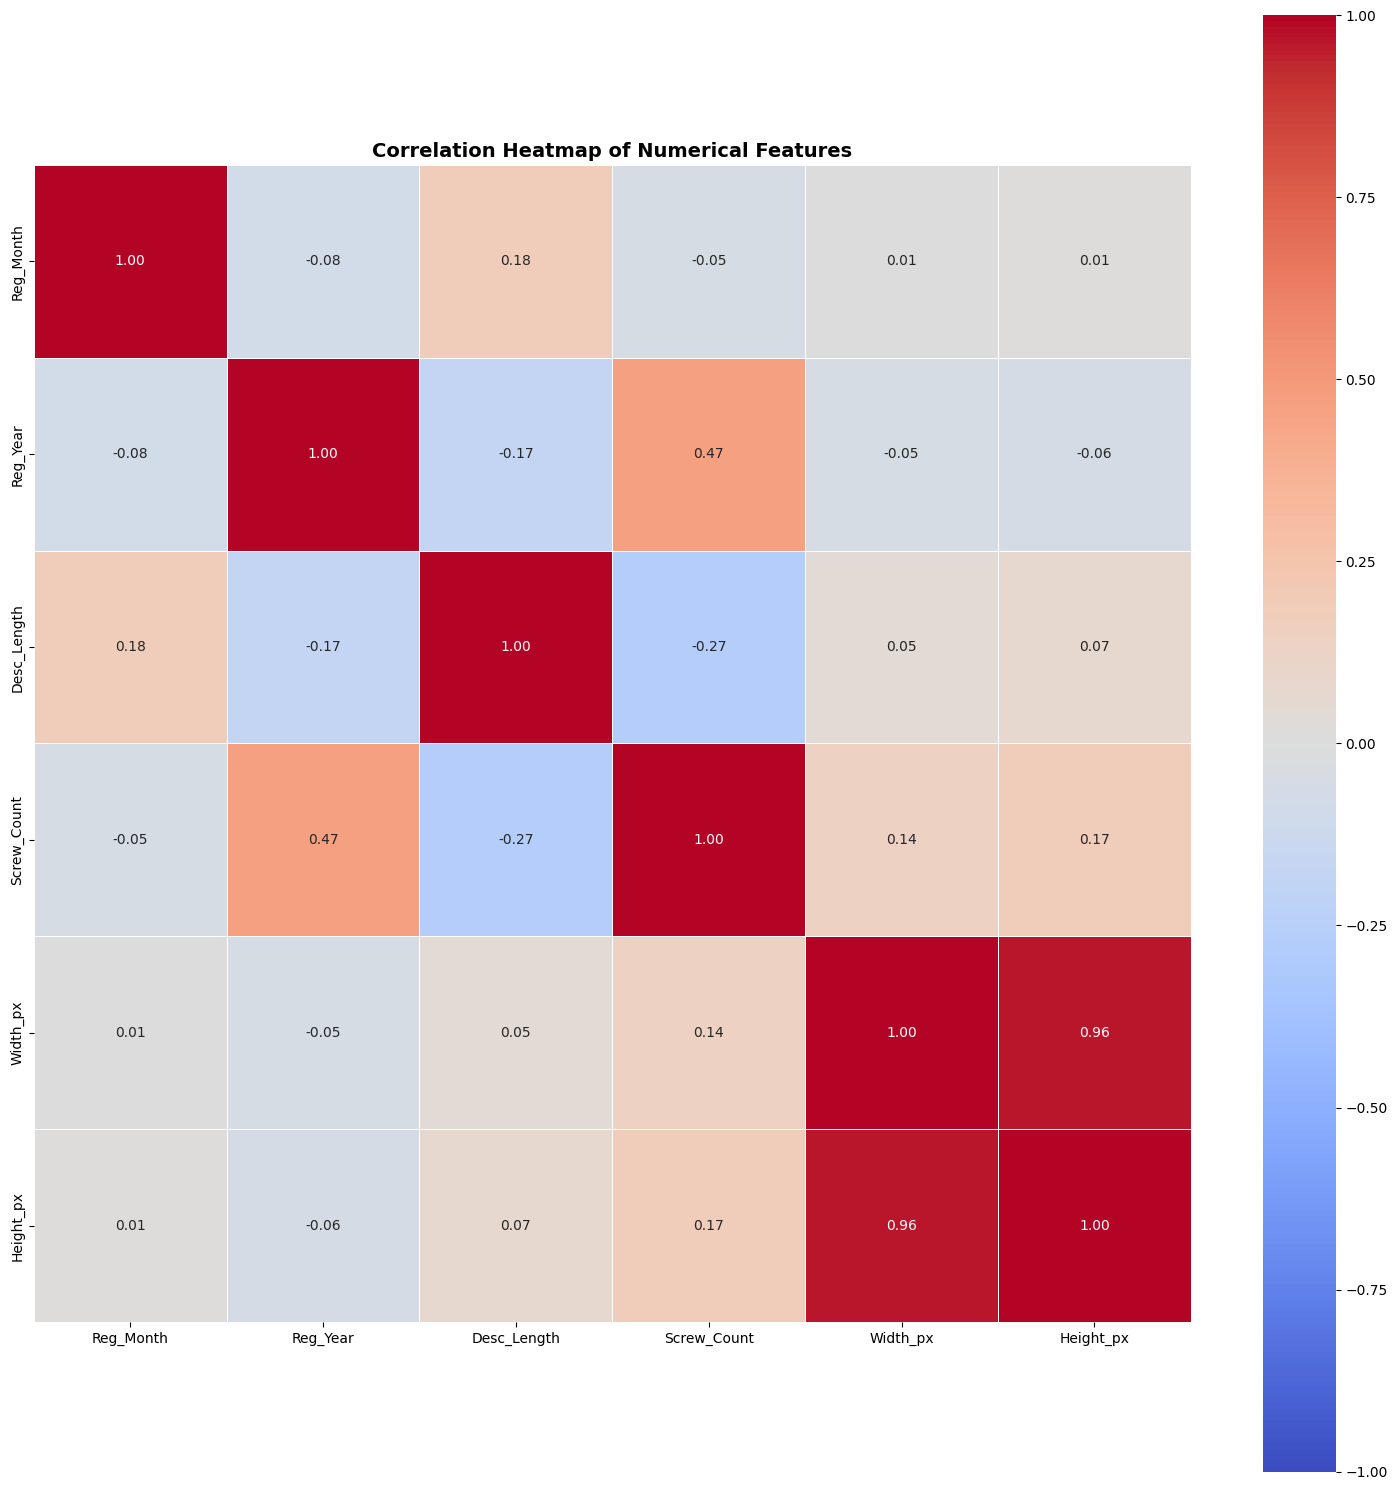

In [ ]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [ ]:

# Export Heatmap
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


In [ ]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs State
# -------------------------------------------------------------
target_col = "State"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()

        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

    print("\nAll EDA tasks completed successfully!")
else:
    print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

Exported boxplot to: /content/boxplot_Reg_Month_vs_State.png
Exported boxplot to: /content/boxplot_Reg_Year_vs_State.png
Exported boxplot to: /content/boxplot_Desc_Length_vs_State.png
Exported boxplot to: /content/boxplot_Screw_Count_vs_State.png
Exported boxplot to: /content/boxplot_Width_px_vs_State.png
Exported boxplot to: /content/boxplot_Height_px_vs_State.png

All EDA tasks completed successfully!


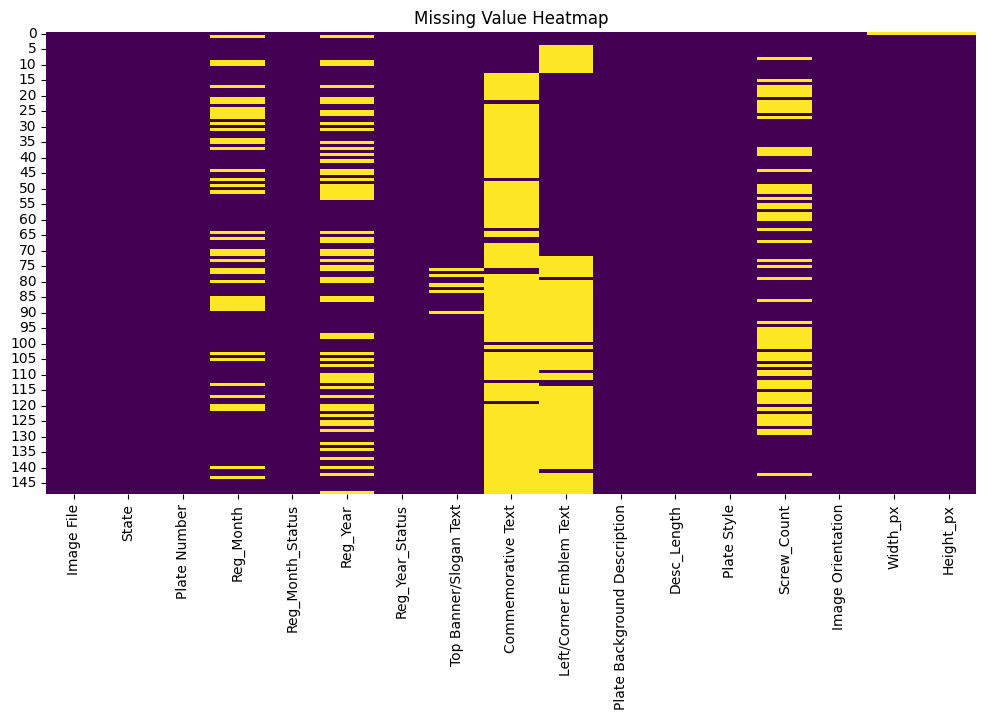

In [ ]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

### **Observation**

The missing value heatmap shows that several features contain missing values — notably `Reg_Month`, `Reg_Year`, `Screw_Count`, `Commemorative Text`, and `Left/Corner Emblem Text` (with `Width_px` and `Height_px` each missing a single value). These gaps should be handled (e.g., imputation or exclusion) before model training.

<Figure size 1500x800 with 0 Axes>

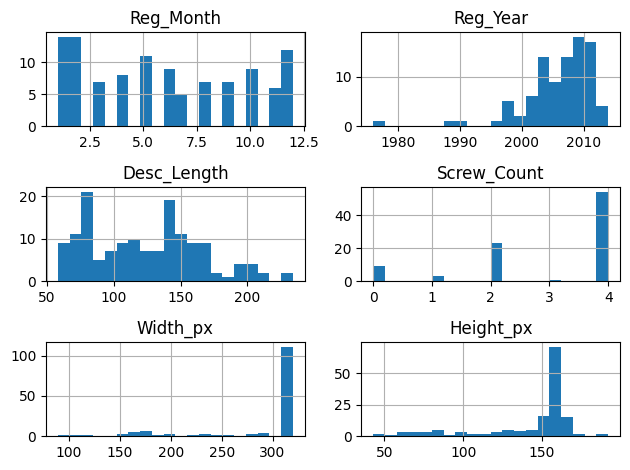

In [ ]:
features = ['Reg_Month', 'Reg_Year', 'Desc_Length', 'Screw_Count', 'Width_px', 'Height_px' ]

fig2=plt.figure(figsize=(15,8))
df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()

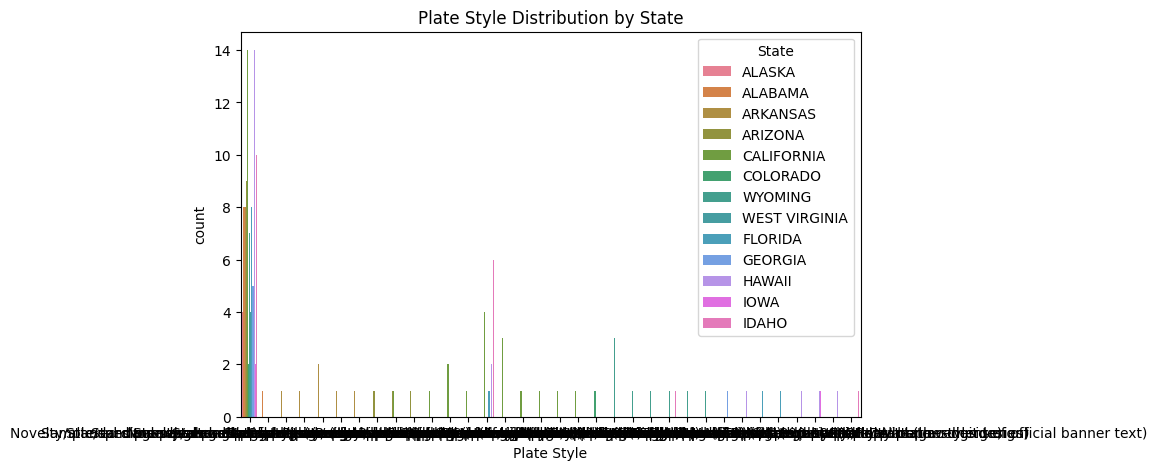

In [ ]:
#Plate Style distribution by State

fig3=plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Plate Style",
    hue="State"
)

plt.title("Plate Style Distribution by State")

plt.show()

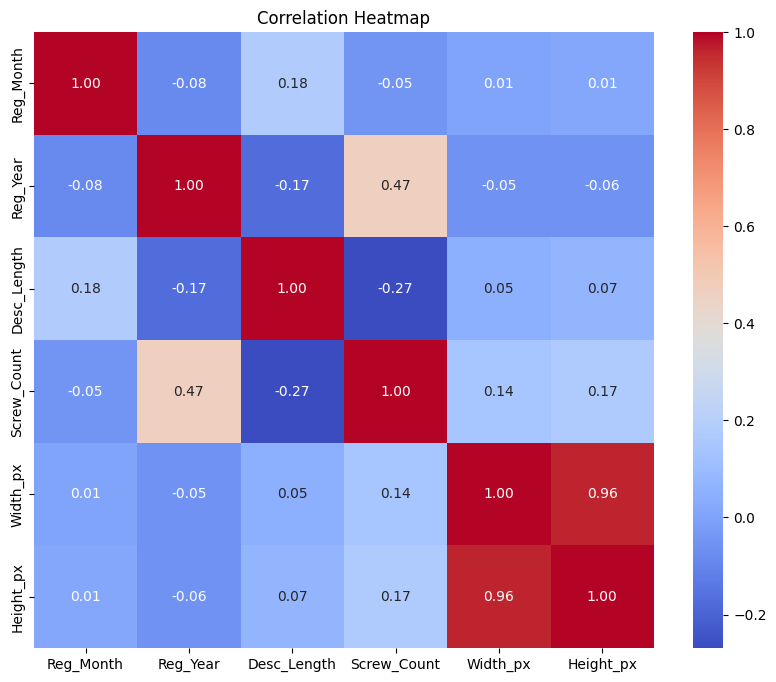

In [ ]:
#Correlation Heatmap

fig5= plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

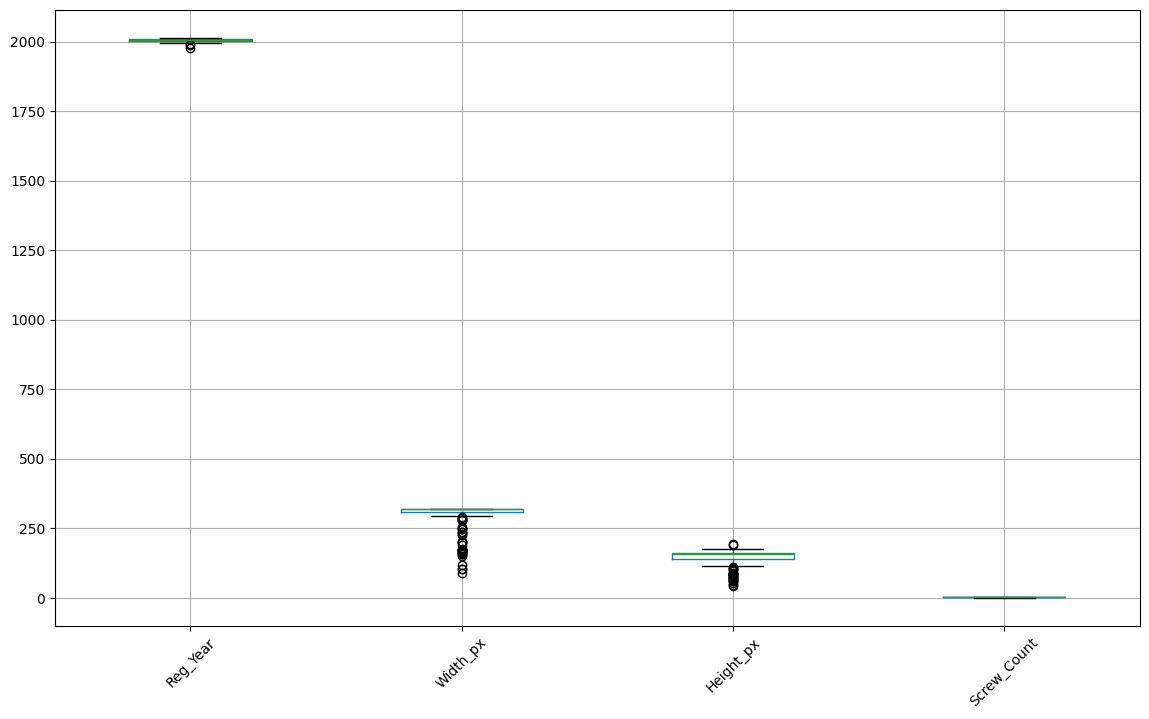

In [ ]:
#boxplots
numerical_columns = [
    "Reg_Year",
    "Width_px",
    "Height_px",
    "Screw_Count"

]


fig6= plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

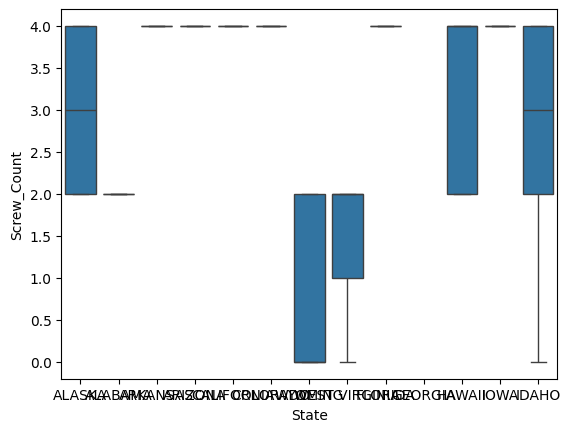

In [ ]:
fig7= sns.boxplot(x='State', y='Screw_Count', data=df)

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)


print("EDA Report saved successfully.")

EDA Report saved successfully.
